In [82]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf


In [83]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train.shape # 60000 images of size 28X28

(60000, 28, 28)

## Data Augmentation 

In [84]:
# Normalize and expand dims for Keras data augmentation
first_image = x_train[0]
normalise_image = first_image.astype('float32')/255.0
normalise_image = np.expand_dims(normalise_image, axis = (0,-1)) # expand to 1 x 28 x 28 x 1
normalise_image.shape 


(1, 28, 28, 1)

Define Roration layer

In [85]:
# Random rotation augmentation
rotation_layer = keras.layers.RandomRotation(factor = 0.1)
rotated_image = rotation_layer(normalise_image)

Text(0.5, 1.0, 'Rotated image')

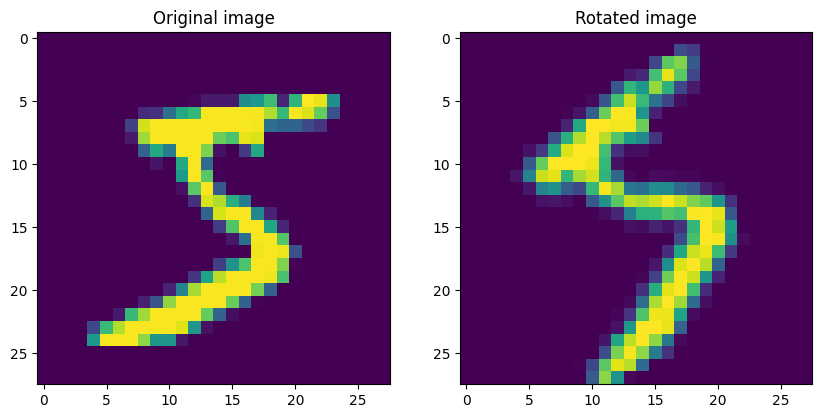

In [86]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(rotated_image.numpy().squeeze())
plt.title('Rotated image')



Random Translation layer 

In [87]:
# Random translation augmentation
translation_layer = keras.layers.RandomTranslation(height_factor=0.5, width_factor=0.5)
translated_image = translation_layer(normalise_image)

Text(0.5, 1.0, 'Translated image')

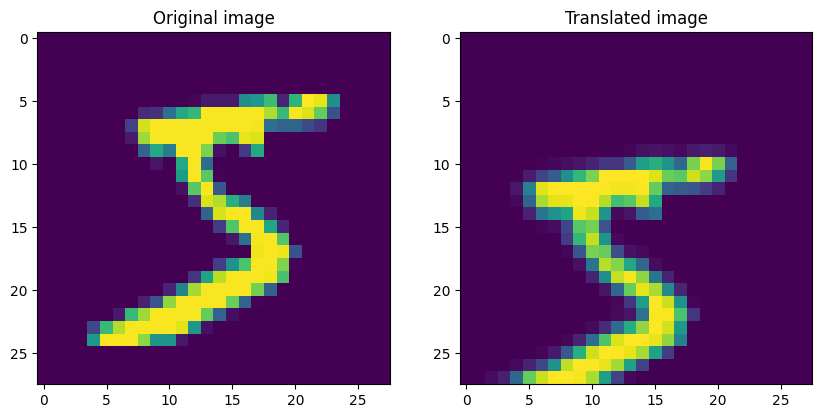

In [88]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(x_train[0])
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(translated_image.numpy().squeeze())
plt.title('Translated image')

## Feature extraction using PCA


To apply Principal Component Analysis, we have to centralise the data

In [89]:
x_train_reshaped = tf.cast(tf.reshape(x_train, [-1, 784]), tf.float32)
mean = tf.reduce_mean(x_train_reshaped, axis = 0)
x_centered = x_train_reshaped - mean



Calculating the coverience matrix

Coverience matrix = $\frac{X^TX}{N-1}$ 
where N = total number of data

In [90]:
N = tf.cast(np.shape(x_centered)[0], tf.float32) 
cov_matrix = tf.matmul(tf.transpose(x_centered), x_centered)/(N-1)
cov_matrix

<tf.Tensor: shape=(784, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 784), dtype=float32)>

Calculating the eigen vectors and eigen values

In [91]:
eigen_values, eigen_vectors = tf.linalg.eigh(cov_matrix)
eigen_values

<tf.Tensor: shape=(784,), dtype=float32, numpy=
array([-7.00123049e-03, -6.20110659e-03, -3.99488397e-03, -3.65191442e-03,
       -2.76664714e-03, -2.00967514e-03, -1.34032150e-03, -1.22390687e-03,
       -9.86511353e-04, -7.93740095e-04, -6.49254827e-04, -4.99753747e-04,
       -3.39131540e-04, -2.40673020e-04, -1.43167956e-04, -8.90521624e-05,
       -5.06118995e-05, -1.53104429e-05, -1.10791516e-05, -1.13714373e-06,
       -3.13532666e-07, -2.45841107e-07, -1.37583925e-07, -4.31630447e-08,
       -2.22549428e-08, -1.88157809e-08, -1.14871024e-09, -6.75329292e-10,
       -1.13890180e-12,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.54161758e-13,  3.40804614e-13,  1.03449855e-12,
        1.80121413e-12,  3.17000874e-12,  1.73756107

Here the eigen values are in acending order. We make it decresing order

In [92]:
eigen_values = eigen_values[::-1]
eigen_vectors = eigen_vectors[:, ::-1]

choosing k = 50 . i.e. we take 50 dominant eigen values (features)

taking the corresponding eigen vectors, we form a new matrix w of shape (784, 50)

In [93]:
k = 50
w = eigen_vectors[:, :k]

the projection matrix $ Y = X \cdot W$

In [94]:
x_pca = tf.matmul(x_centered, w)
print("Original data shape:", x_train.shape)
print("PCA projected shape:", x_pca.shape)

Original data shape: (60000, 28, 28)
PCA projected shape: (60000, 50)


## Apply LBP and HOG

In [124]:
from skimage.feature import local_binary_pattern
from skimage import color
def extract_LBP_features(images):
    lbp_features = []
    for image in images:
        lbp_image = local_binary_pattern(image, P=8 , R = 2, method = 'uniform')
        # since lbp_image in of the shape 28x28 , we flatten it
        lbp_features.append(lbp_image.flatten())

        return np.array(lbp_features)

x_train_lbp = extract_LBP_features(x_train)
print(f'Original shape: {x_train.shape}')
print(f'LBP feature shape: {x_train_lbp.shape}')


Original shape: (60000, 28, 28)
LBP feature shape: (1, 784)


Text(0.5, 1.0, 'LBP image')

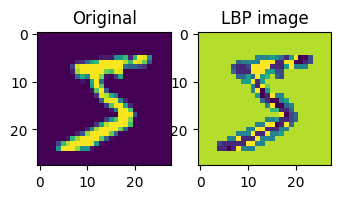

In [126]:
image = x_train[0]
lbp = local_binary_pattern(image, 8, 2 , method = 'uniform')
plt.figure(figsize = (10, 5))
plt.subplot(1,5, 1)
plt.imshow(image)
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(lbp)
plt.title('LBP image')